# 5-3 좀 더 복잡한 이미지를 다루는 딥러닝

본 노트북은 본문 5-3 절의 코드 예제([코드 5-13] ~ [코드 5-22])를 절 흐름 그대로 모은 것이다. CIFAR-10 컬러 이미지 분류기를 만들고, 데이터 증강·드롭아웃으로 과적합을 완화하며, 하드웨어 가속기를 활용한다.

다루는 내용
- `[코드 5-13]` CIFAR-10 데이터 준비, `[코드 5-14]` 분류 모델
- `[코드 5-15]` 기본 학습, `[코드 5-16]`~`[코드 5-18]` 데이터 증강
- `[코드 5-19]` 드롭아웃, `[코드 5-20]`~`[코드 5-22]` 하드웨어 가속기

> CIFAR-10 자동 다운로드 데이터는 `root='../../download'` 로 받는다(본문 경로 `'../data'` 와의 차이는 `_book` 에 기록).
> 학습 함수는 5-2 절과 동일하며, 본문 각주[^5]대로 검증 손실 최솟값 갱신 시에만 로그를 출력한다.

## 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)

torchvision 은 기본 의존성으로 README 에서 안내한다.

In [2]:
# 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)
# !pip install -q torchvision

## 라이브러리 import 와 시드 고정

In [3]:
# 참고 - 환경 설정 (code_reference 모듈 임포트 경로와 시각화 설정)
import sys
sys.path.append('../../')

from code_reference import common
# viz.configure()에서 save_grayscale=True로 지정하면 노트북에 표시되는 시각화 이미지를 파일로 저장함
from code_reference import visualize as viz

common.set_korean_plot_env()
viz.configure(save_grayscale=False)

In [4]:
# 참고 - 라이브러리 import 와 시드 고정
import copy
import random
import time

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## [코드 5-13] 데이터 준비 (훈련, 검증, 평가 데이터로더 생성)

CIFAR-10 은 32x32 크기의 3채널 컬러 이미지다. 표준화 변환의 평균·표준편차는 채널별 튜플로 지정한다. 50,000 훈련 샘플을 40,000(훈련) + 10,000(검증)으로 나눈다.

In [5]:
# 코드 5-13 - 데이터 준비 과정 (훈련, 검증, 평가 데이터로더 생성)

# 텐서 변환과 표준화 변환으로 구성된 데이터 변환 객체
# 표준화 변환의 기준 평균과 표준편차는 채널별 튜플로 지정해야 함
cifar10_mean = (0.5, 0.5, 0.5)
cifar10_std  = (0.5, 0.5, 0.5)
transform_chain = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar10_mean, cifar10_std),
])

# data_root: 데이터셋 다운로드 경로
data_root = '../../download'

# CIFAR 내장 데이터셋으로 train_set (train=True)과 test_set 생성
train_set = datasets.CIFAR10(root=data_root, train=True, download=True, transform=transform_chain)
test_set = datasets.CIFAR10(root=data_root, train=False, download=True, transform=transform_chain)

# train_set 을 40,000개의 훈련 데이터셋과 10,000개의 검증 데이터셋으로 분리
train_set, valid_set = random_split(
    train_set, [40000, 10000],                      # 훈련 데이터셋과 검증 데이터셋의 샘플 수
    generator=torch.Generator().manual_seed(SEED),  # 난수 발생기 (시드값 SEED 지정)
)

# 훈련, 검증, 평가 데이터로더 생성
BATCH_SIZE = 128                                    # 배치 크기: 2의 거듭제곱수 추천
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f'훈련 샘플 수: {len(train_set)}')
print(f'검증 샘플 수: {len(valid_set)}')
print(f'평가 샘플 수: {len(test_set)}')
print(f'이미지 텐서 형태: {tuple(train_set[0][0].shape)}')   # (3, 32, 32)

훈련 샘플 수: 40000
검증 샘플 수: 10000
평가 샘플 수: 10000
이미지 텐서 형태: (3, 32, 32)


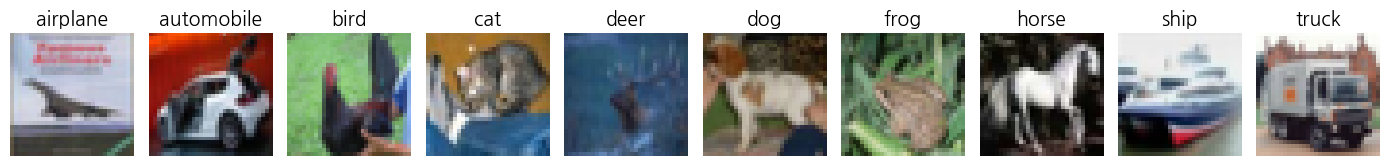

In [6]:
# 참고 - 본문 [그림 5-14] 대응: CIFAR-10 클래스별 예시 이미지
class_names = datasets.CIFAR10(
    root=data_root, train=False, download=False,
).classes

# 각 클래스의 첫 등장 샘플 인덱스를 찾아 시각화
raw_test = datasets.CIFAR10(
    root=data_root, train=False,
    download=False, transform=transforms.ToTensor(),
)
first_indices = {}
for idx in range(len(raw_test)):
    _, lbl = raw_test[idx]
    if lbl not in first_indices:
        first_indices[lbl] = idx
    if len(first_indices) == 10:
        break

imgs = [raw_test[first_indices[c]][0] for c in range(10)]
descs = [class_names[c] for c in range(10)]
viz.plot_images(imgs, descs, images_per_row=10)

## [코드 5-14] CIFAR-10 분류 합성곱 신경망 모델

5-2 절의 `ConvBlock` 을 재사용한다. 첫 블록은 5x5 필터(`padding=2`)로 수용 영역을 빠르게 확장하고, 분류기에 은닉층을 두어 복합적인 특징을 분류한다.

In [7]:
# 코드 5-14 - CIFAR-10 분류 합성곱 신경망 모델

# ConvBlock: 합성곱 계층, ReLU 활성화 계층, 최대 풀링 계층으로 구성 (코드 5-10)
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels,
                 kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

    def forward(self, x):
        return self.conv_block(x)


# 합성곱 신경망을 사용하는 CIFAR-10 이미지 분류기 모델 클래스
class CIFAR10ConvClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        # 특징 추출기: 두 개의 합성곱 블록
        # 첫 번째 합성곱 블록: 5x5 필터, padding=2로 수용 영역을 빠르게 확장
        # CIFAR-10은 3채널 컬러 이미지이므로 첫 번째 블록의 입력 채널은 3
        self.conv_block_1 = ConvBlock(in_channels=3, out_channels=16,
                                      kernel_size=5, stride=1, padding=2)
        # 두 번째 합성곱 블록: 3x3 필터, padding=1
        self.conv_block_2 = ConvBlock(in_channels=16, out_channels=32,
                                      kernel_size=3, stride=1, padding=1)
        # 분류기: 완전 연결 계층(은닉층 -> 출력층으로 구성)
        self.classifier = nn.Sequential(
            nn.Flatten(),                   # (B, 32, 8, 8) -> (B, 2048)
            nn.Linear(32 * 8 * 8, 256),     # (B, 2048) -> (B, 256)
            nn.ReLU(),
            nn.Linear(256, 10),             # (B, 256) -> (B, 10)
        )

    def forward(self, x):
        x = self.conv_block_1(x)            # (B, 3, 32, 32) -> (B, 16, 16, 16)
        x = self.conv_block_2(x)            # (B, 16, 16, 16) -> (B, 32, 8, 8)
        x = self.classifier(x)              # (B, 32, 8, 8) -> (B, 10)
        return x


model = CIFAR10ConvClassifier()
print(model)

CIFAR10ConvClassifier(
  (conv_block_1): ConvBlock(
    (conv_block): Sequential(
      (0): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (conv_block_2): ConvBlock(
    (conv_block): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


## 참고 - 학습 함수 정의 (4장/5-2 절과 동일한 분해 구조)

5-2 절과 같은 학습 함수를 재사용한다. 검증 손실 최솟값이 갱신되는 에포크에서만 로그를 출력하며, 전체 학습 시간도 함께 측정한다.

In [8]:
# 참고 - 학습 함수는 5-2절의 미니배치, 조기 종료 학습 함수를 그대로 사용

# 1 에포크의 모델 파라미터를 최적화하는 학습 함수
def train_batch(model, X_train, Y_train, criterion, optimizer):    
    model.train()                                       # 학습 모드
    Y_train_pred = model(X_train)
    train_loss = criterion(Y_train_pred, Y_train)       # 훈련 손실 계산
    optimizer.zero_grad()
    train_loss.backward()                               # 훈련 손실로 역전파
    optimizer.step()
    return train_loss.item()

# 모델 성능을 검증하는 평가 함수
def validate(model, X_valid, Y_valid, criterion):
    model.eval()                                        # 평가 모드
    with torch.no_grad():
        Y_valid_pred = model(X_valid)
        valid_loss = criterion(Y_valid_pred, Y_valid)   # 검증 손실 계산
    return valid_loss.item()

# 조기 종료를 적용한 학습 루프 함수
def train_with_early_stopping(model,
                              train_loader, valid_loader,
                              criterion, optimizer, epochs, patience):
    # 표준 학습 로거 생성
    log = common.EpochLogger(epochs, columns=('훈련 손실', '검증 손실'),
                             formats=('{:.4f}', '{:.4f}'), target_rows=epochs)
    # 조기 종료를 위한 변수 초기화
    best_valid_loss = float('inf')  # 지금까지의 최소 검증 손실: 충분히 큰 값으로 초기화
    best_model_params = None        # 검증 손실이 최소일 때의 파라미터를 저장할 딕셔너리
    patience_counter = 0            # 참을성 카운터
    best_epoch = 0                  # 최적 에포크: 검증 손실이 최소일 때의 에포크

    for epoch in range(1, epochs + 1):
        # 훈련, 검증 손실의 가중합과 훈련, 검증 샘플 수 누적 변수: 에포크마다 초기화
        train_loss_sum, valid_loss_sum = 0, 0
        train_sample_size, valid_sample_size = 0, 0

        # 최적화 단계: train_batch()는 train_epoch()와 같지만 최적화 단위가 배치로 바뀜
        # 미니배치를 반복해 1 에포크 구성
        for X_train, Y_train in train_loader:
            # X_train, Y_train: 미니배치를 구성하는 입력과 정답 텐서
            train_loss = train_batch(model, X_train, Y_train, criterion, optimizer)
            # 각 배치별 가중 평균으로 손실값 계산 (미니배치마다 샘플의 수가 다를 수 있음)
            minibatch_size = X_train.size(0)                   # 미니배치의 샘플 수
            train_sample_size += minibatch_size                # 전체 샘플 수 누적 계산
            train_loss_sum += train_loss * minibatch_size      # 가중합
        train_loss_avg = train_loss_sum / train_sample_size    # 가중 평균

        # 검증 단계: validate()도 검증 단위가 배치로 바뀌며, 가중 평균으로 검증 손실 계산
        for X_valid, Y_valid in valid_loader:
            valid_loss = validate(model, X_valid, Y_valid, criterion)
            minibatch_size = X_valid.size(0)
            valid_sample_size += minibatch_size
            valid_loss_sum += valid_loss * minibatch_size
        valid_loss_avg = valid_loss_sum / valid_sample_size

        # 학습 로그 저장 및 출력
        log.row(epoch, train_loss_avg, valid_loss_avg)

        # 조기 종료 판단
        if valid_loss_avg < best_valid_loss:
            # 최소 검증 손실보다 작은 경우 (현재가 최소 검증 손실)
            best_valid_loss = valid_loss_avg                        # 최소 검증 손실 갱신
            best_model_params = copy.deepcopy(model.state_dict())   # 최소 검증 손실 시점의 파라미터 저장
            best_epoch = epoch                                      # 최소 손실 에포크 갱신
            patience_counter = 0                                    # 참을성 카운터 초기화
        else:
            # 최소 검증 손실이 갱신되지 않은 경우
            patience_counter += 1                                   # 참을성 카운터 1 증가
            if patience_counter >= patience:                        # 한계 초과 시 조기 종료                
                break

    print(f'최적({best_epoch} 에포크/검증 손실 {best_valid_loss:.4f}) 파라미터로 모델 복원')
    model.load_state_dict(best_model_params)
    return log

In [9]:
# # 참고 - 학습 함수 (4장/5-2 절과 동일한 분해 구조, 로그는 EpochLogger 표준)
# def train_epoch(model, train_loader, criterion, optimizer):
#     """1 에포크 학습 - 가중 평균 손실을 반환."""
#     model.train()
#     loss_sum, sample_size = 0.0, 0
#     for inputs, labels in train_loader:
#         optimizer.zero_grad()
#         outputs = model(inputs)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()
#         loss_sum += loss.item() * inputs.size(0)
#         sample_size += inputs.size(0)
#     return loss_sum / sample_size


# @torch.no_grad()
# def evaluate(model, loader, criterion):
#     """검증/평가 손실과 정확도를 반환."""
#     model.eval()
#     loss_sum, correct_size, sample_size = 0.0, 0, 0
#     for inputs, labels in loader:
#         outputs = model(inputs)
#         loss = criterion(outputs, labels)
#         loss_sum += loss.item() * inputs.size(0)
#         correct_size += (outputs.argmax(dim=1) == labels).sum().item()
#         sample_size += inputs.size(0)
#     return loss_sum / sample_size, correct_size / sample_size


# def train_with_early_stopping(model, train_loader, valid_loader,
#                               criterion, optimizer, epochs, patience):
#     """미니배치 + 조기 종료 학습 루프. 로그는 EpochLogger 표준."""
#     # 분류 학습이므로 표준 3 열(훈련 손실·검증 손실·정확도(%))을 사용한다.
#     log = common.EpochLogger(epochs, target_rows=epochs)
#     best_valid_loss = float('inf')
#     best_model_params = None
#     patience_counter = 0
#     stopped_early = False
#     for epoch in range(1, epochs + 1):
#         train_loss = train_epoch(
#             model, train_loader, criterion, optimizer
#         )
#         valid_loss, valid_acc = evaluate(model, valid_loader, criterion)
#         # 정확도는 백분율 수(0~100)로 기록한다.
#         log.row(epoch, train_loss, valid_loss, valid_acc * 100)
#         if valid_loss < best_valid_loss:
#             best_valid_loss = valid_loss
#             best_model_params = copy.deepcopy(model.state_dict())
#             patience_counter = 0
#         else:
#             patience_counter += 1
#             if patience_counter >= patience:
#                 stopped_early = True
#                 break
#     # 최소 검증 손실 시점(log.best_epoch)의 파라미터로 모델 복원
#     model.load_state_dict(best_model_params)
#     log.summary(stopped='조기 종료' if stopped_early else None)
#     return log


In [10]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## [코드 5-15] 기본 CIFAR-10 분류 합성곱 신경망 모델의 학습 결과

MNIST 숫자 분류기와 동일한 하이퍼파라미터·학습 함수로 학습한다(코드 예제는 본문에서 생략). 훈련·평가 정확도 차이가 커 과적합이 의심된다.

epoch    훈련 손실    검증 손실     시간
 1/20       1.5013       1.2783     0:13
 2/20       1.1932       1.1388     0:26
 3/20       1.0451       1.0520     0:40
 4/20       0.9292       0.9786     0:54
 5/20       0.8351       0.9142     1:07
 6/20       0.7546       0.9228     1:20
 7/20       0.6763       0.8828     1:34
 8/20       0.6018       0.9330     1:47
 9/20       0.5330       0.8996     2:00
10/20       0.4662       0.9675     2:13
11/20       0.4018       0.9843     2:27
12/20       0.3332       1.0338     2:41
최적(7 에포크/검증 손실 0.8828) 파라미터로 모델 복원


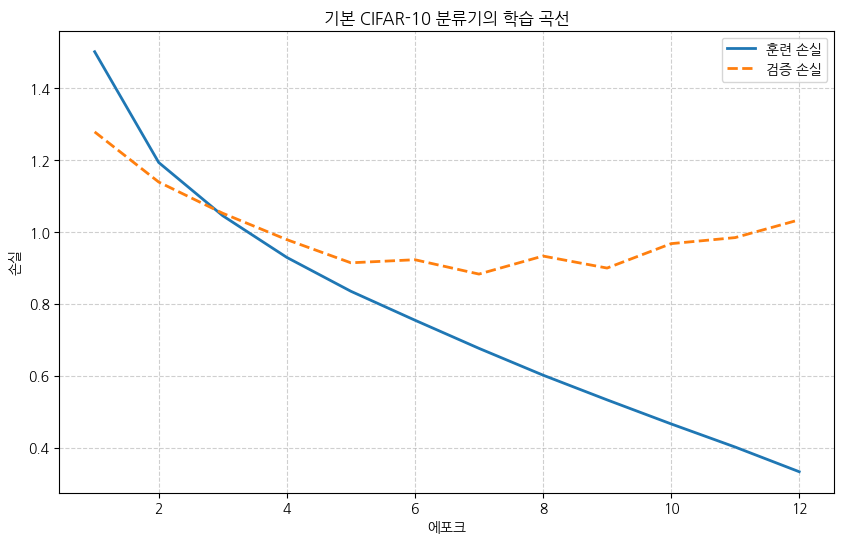

In [11]:
# 참고 - 기본 CIFAR-10 분류 합성곱 신경망 모델의 학습 결과
model = CIFAR10ConvClassifier()

# 학습 환경 설정
LR = 0.001
EPOCHS = 20
PATIENCE = 5
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

# 모델 학습
log_base = train_with_early_stopping(
    model, train_loader, valid_loader, criterion, optimizer,
    EPOCHS, PATIENCE
)

# 학습 곡선 그래프
log_base.plot(title='기본 CIFAR-10 분류기의 학습 곡선', y_label='손실')


In [12]:
# 참고 - 훈련 데이터셋과 평가 데이터셋의 분류 정확도

train_eval_loader = DataLoader(train_set, batch_size=BATCH_SIZE)
# common.get_accuracy() 함수: 모델, 데이터로더를 입력받아 정확도, 정답 수, 샘플 수를 반환
acc_train_base, _, _ = common.get_accuracy(model, train_eval_loader)
acc_test_base, _, _ = common.get_accuracy(model, test_loader)
print(f'훈련 데이터셋 분류 정확도: {acc_train_base:.2f}%')
print(f'평가 데이터셋 분류 정확도: {acc_test_base:.2f}%')

훈련 데이터셋 분류 정확도: 80.97%
평가 데이터셋 분류 정확도: 69.33%


## [코드 5-16] 데이터 증강 변환을 추가한 훈련 데이터셋 전용 데이터 변환 객체

50% 확률로 좌우 반전하는 증강 변환을 추가한다. 증강은 훈련 데이터셋에만 적용한다.

In [13]:
# 코드 5-15 - 데이터 증강 변환을 추가한 훈련 데이터셋 전용 데이터 변환 객체

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),     # 50% 확률로 좌우 반전 (기본값 0.5)
    transforms.ToTensor(),
    transforms.Normalize(cifar10_mean, cifar10_std),
])
print(train_transform)

Compose(
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
)


## [코드 5-17] 훈련 데이터셋에만 증강 변환을 추가해 만든 데이터로더

증강 변환을 적용한 데이터셋과 적용하지 않은 데이터셋을 만들어 **같은 시드**로 분리하면, 훈련엔 증강을 적용하고 검증엔 적용하지 않으면서 두 집합이 겹치지 않게 할 수 있다.

In [14]:
# 코드 5-16 - 훈련 데이터셋에만 증강 변환을 추가해 만든 데이터로더

# 증강 변환을 포함해 훈련 데이터셋 생성
train_set = datasets.CIFAR10(root=data_root, train=True, download=True, transform=train_transform)

# 증강 변환 없이 검증 데이터셋 생성
# 기존의 transform_chain(RandomHorizontalFlip 미적용) 사용
valid_set = datasets.CIFAR10(root=data_root, train=True, download=True, transform=transform_chain)

# 동일한 SEED 로 분리해야 훈련과 검증 데이터셋의 샘플이 겹치지 않는다.
train_set, _ = random_split(train_set, [40000, 10000],
                            generator=torch.Generator().manual_seed(SEED))
_, valid_set = random_split(valid_set, [40000, 10000], 
                            generator=torch.Generator().manual_seed(SEED))

# 데이터로더 생성
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)

# 평가 데이터로더는 기존과 동일
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f'증강 훈련 샘플 수: {len(train_set)}')
print(f'증강 미적용 검증 샘플 수: {len(valid_set)}')

증강 훈련 샘플 수: 40000
증강 미적용 검증 샘플 수: 10000


In [15]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## [코드 5-18] 증강 변환(50% 확률 좌우 반전)을 적용한 데이터로 모델을 학습한 결과

증강을 적용하면 과적합이 늦춰져 최적 에포크가 늘고, 일반화 성능이 개선된다.

In [16]:
# 참고 - 증강 변환(50% 확률 좌우 반전)을 적용한 데이터로 모델을 학습한 결과
model_aug = CIFAR10ConvClassifier()
optimizer = optim.Adam(model_aug.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

EPOCHS = 20
log_aug = train_with_early_stopping(
    model_aug, train_loader, valid_loader, criterion, optimizer,
    EPOCHS, PATIENCE
)
acc_train_aug, _, _ = common.get_accuracy(model_aug, train_eval_loader)
acc_test_aug, _, _ = common.get_accuracy(model_aug, test_loader)
print(f'훈련 데이터셋 분류 정확도: {acc_train_aug:.2f}%')
print(f'평가 데이터셋 분류 정확도: {acc_test_aug:.2f}%')


epoch    훈련 손실    검증 손실     시간
 1/20       1.4885       1.2660     0:15
 2/20       1.1901       1.1449     0:30
 3/20       1.0494       1.0065     0:44
 4/20       0.9533       0.9527     0:59
 5/20       0.8798       0.9302     1:13
 6/20       0.8220       0.8922     1:27
 7/20       0.7631       0.8448     1:42
 8/20       0.7137       0.8427     1:56
 9/20       0.6628       0.8563     2:11
10/20       0.6276       0.8285     2:25
11/20       0.5813       0.8112     2:40
12/20       0.5443       0.8221     2:54
13/20       0.5098       0.8437     3:08
14/20       0.4678       0.8611     3:24
15/20       0.4375       0.8514     3:39
16/20       0.4018       0.9005     3:54
최적(11 에포크/검증 손실 0.8112) 파라미터로 모델 복원
훈련 데이터셋 분류 정확도: 82.31%
평가 데이터셋 분류 정확도: 72.26%


## [코드 5-19] 드롭아웃 계층을 추가한 CIFAR-10 분류기 모델 클래스

분류기의 은닉층과 출력층 사이에 `p=0.5` 인 드롭아웃 계층을 추가한다. 드롭아웃은 학습 모드에서만 동작하고 평가 모드에서는 동작하지 않는다.

In [17]:
# 코드 5-17 - 드롭아웃 계층을 추가한 CIFAR-10 분류기 모델 클래스

# 드롭아웃 계층을 추가한 CIFAR-10 이미지 분류기 모델 클래스
class CIFAR10ConvClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_block_1 = ConvBlock(in_channels=3, out_channels=16,
                                      kernel_size=5, stride=1, padding=2)
        self.conv_block_2 = ConvBlock(in_channels=16, out_channels=32,
                                      kernel_size=3, stride=1, padding=1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(p=0.5),          # 50% 확률로 출력을 0으로 바꾸는 드롭아웃 계층
            nn.Linear(256, 10),
        )

    def forward(self, x):
        x = self.conv_block_1(x)        # (B, 3, 32, 32) -> (B, 16, 16, 16)
        x = self.conv_block_2(x)        # (B, 16, 16, 16) -> (B, 32, 8, 8)
        x = self.classifier(x)          # (B, 32, 8, 8) -> (B, 10)
        return x


model_drop = CIFAR10ConvClassifier()
print(model_drop)

CIFAR10ConvClassifier(
  (conv_block_1): ConvBlock(
    (conv_block): Sequential(
      (0): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (conv_block_2): ConvBlock(
    (conv_block): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [18]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [19]:
# 참고 - 드롭아웃 추가 모델 학습
model_aug = CIFAR10ConvClassifier()
optimizer = optim.Adam(model_aug.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

EPOCHS = 30
log_aug = train_with_early_stopping(
    model_aug, train_loader, valid_loader, criterion, optimizer,
    EPOCHS, PATIENCE
)
acc_train_aug, _, _ = common.get_accuracy(model_aug, train_eval_loader)
acc_test_aug, _, _ = common.get_accuracy(model_aug, test_loader)
print(f'훈련 데이터셋 분류 정확도: {acc_train_aug:.2f}%')
print(f'평가 데이터셋 분류 정확도: {acc_test_aug:.2f}%')


epoch    훈련 손실    검증 손실     시간
 1/30       1.6076       1.3204     0:15
 2/30       1.3278       1.1609     0:30
 3/30       1.1995       1.0798     0:45
 4/30       1.1168       1.0144     1:00
 5/30       1.0548       0.9896     1:15
 6/30       0.9923       0.9329     1:30
 7/30       0.9555       0.8931     1:44
 8/30       0.9157       0.8791     1:59
 9/30       0.8933       0.8492     2:14
10/30       0.8605       0.8474     2:29
11/30       0.8353       0.8177     2:43
12/30       0.8142       0.8221     2:59
13/30       0.7917       0.8069     3:14
14/30       0.7766       0.8040     3:29
15/30       0.7530       0.8005     3:45
16/30       0.7361       0.7935     4:01
17/30       0.7220       0.7845     4:16
18/30       0.7102       0.7926     4:30
19/30       0.6948       0.7912     4:45
20/30       0.6848       0.7878     5:00
21/30       0.6716       0.7917     5:15
22/30       0.6551       0.8111     5:30
최적(17 에포크/검증 손실 0.7845) 파라미터로 모델 복원
훈련 데이터셋 분류 정확도: 81.20%
평가 데이터셋 

## [코드 5-20] 사용 조건에 따라 장치 객체 생성

실행 환경의 하드웨어 가속기를 미리 알 수 없을 때는 사용 가능 조건을 확인한 뒤 장치 객체를 만든다. 다음 장부터는 같은 동작을 하는 `common.get_device()` 한 줄로 대체한다.

In [20]:
# 코드 5-18 - 사용 조건에 따라 장치 객체 생성

if torch.cuda.is_available():                       # cuda 사용 조건 확인
    device = torch.device('cuda')
elif torch.backends.mps.is_available():             # mps 사용 조건 확인
    device = torch.device('mps')
else:                                               # 둘 다 사용할 수 없는 경우
    device = torch.device('cpu')

# print() 함수로 장치 객체를 출력해 확인 가능
print(f'현재의 하드웨어 가속기 장치: {device}')     # 출력 결과: mps, cuda, cpu 등

현재의 하드웨어 가속기 장치: cuda


In [21]:
# 코드 5-19 - 모델과 텐서를 하드웨어 가속기로 이동시켜 모델 학습하기

# device 인자를 추가해 1 에포크 모델 파라미터를 최적화하는 학습 함수
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    loss_sum, sample_size = 0.0, 0
    for inputs, labels in train_loader:
        #입력, 정답 텐서를 device로 이동, 텐서의 to() 메서드는 제자리 연산 메서드가 아님
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()                       # 기울기 초기화
        outputs = model(inputs)                     # 모델 순전파
        loss = criterion(outputs, labels)           # 손실 계산
        loss.backward()                             # 역전파
        optimizer.step()                            # 최적화
        loss_sum += loss.item() * inputs.size(0)
        sample_size += inputs.size(0)
    return loss_sum / sample_size                   # 훈련 손실(가중 평균) 반환

# @torch.no_grad() 데코레이터: 함수 전체를 no_grad() 컨텍스트로 감쌈
@torch.no_grad()
# device 인자를 추가해 모델을 평가하는 검증 함수(검증 손실, 정확도 반환)
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, correct_size, sample_size = 0.0, 0, 0
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss_sum += loss.item() * inputs.size(0)
        correct_size += (outputs.argmax(dim=1) == labels).sum().item()
        sample_size += inputs.size(0)
    return loss_sum / sample_size, correct_size / sample_size

# device 인자를 추가해 모델을 조기 종료 방식으로 학습하는 학습 루프 함수
def train_with_early_stopping(model, train_loader, valid_loader,
                              criterion, optimizer, epochs, patience,
                              device=None):
    # device 가 지정되지 않으면 cpu로 지정(예외 발생 예방)
    if device is None: device = torch.device('cpu')
    # 모델을 device로 이동, 모델의 to() 메서드는 제자리 연산 메서드임
    model.to(device)
    
    log = common.EpochLogger(epochs, target_rows=epochs)

    best_valid_loss = float('inf')
    best_model_params = None
    patience_counter = 0
    best_epoch = 0
    for epoch in range(1, epochs + 1):
        # device 인자를 추가해 학습 함수, 검증 함수 호출
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        valid_loss, valid_acc = evaluate(model, valid_loader, criterion, device)                
        # 학습 로그 저장 및 출력
        log.row(epoch, train_loss, valid_loss, valid_acc * 100)
        # 조기 종료 판단
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_model_params = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
    # 최소 검증 손실 시점의 파라미터로 모델 복원
    print(f'최적({best_epoch} 에포크/검증 손실 {best_valid_loss:.4f}) 파라미터로 모델 복원')
    model.load_state_dict(best_model_params)
    return log


In [22]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## [코드 5-21] 모델과 텐서를 하드웨어 가속기로 이동시켜 모델 학습하기

학습 함수는 데이터로더에서 가져온 텐서를 `.to(device)` 로 옮긴다(이미 5-2 절 학습 함수에 반영됨). 모델은 옵티마이저 생성 전에 `model.to(device)` 로 옮긴다. 본문 코드는 학습 함수의 텐서 이동·모델 이동 핵심부만 발췌하며, 여기서는 전체 흐름을 실행한다.

epoch    훈련 손실    검증 손실    정확도(%)     시간
 1/30       1.6013       1.3178       53.68%     0:10
 2/30       1.3187       1.2163       56.89%     0:19
 3/30       1.1934       1.0753       61.58%     0:29
 4/30       1.0980       1.0025       64.14%     0:38
 5/30       1.0313       0.9526       66.19%     0:47
 6/30       0.9853       0.9252       67.32%     0:56
 7/30       0.9406       0.8922       68.68%     1:05
 8/30       0.9020       0.8845       68.82%     1:14
 9/30       0.8718       0.8504       70.57%     1:23
10/30       0.8440       0.8195       71.31%     1:32
11/30       0.8163       0.8250       71.16%     1:41
12/30       0.7938       0.8048       71.86%     1:51
13/30       0.7749       0.8227       71.38%     2:00
14/30       0.7491       0.8110       71.86%     2:09
15/30       0.7370       0.7836       72.57%     2:18
16/30       0.7131       0.7912       72.67%     2:27
17/30       0.7075       0.7786       72.86%     2:36
18/30       0.6861       0.7856       72.

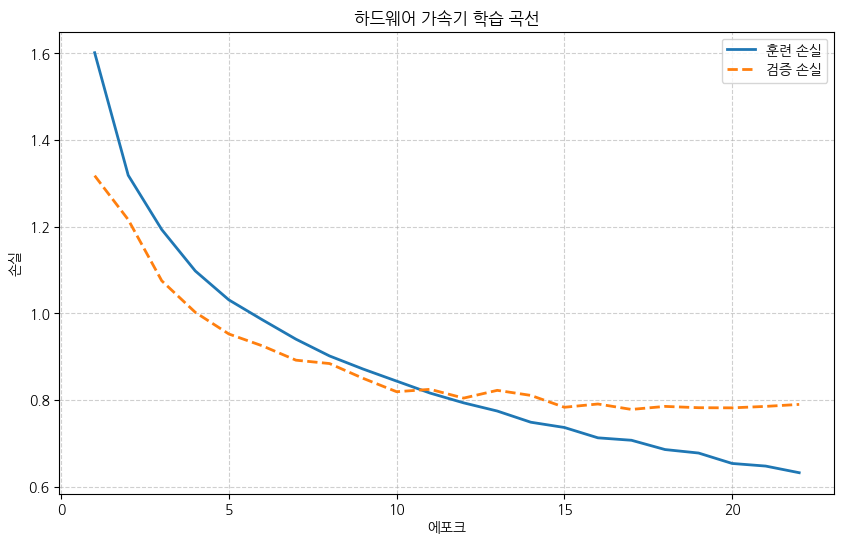

하드웨어 가속기에서의 평가 정확도: 72.71%


In [23]:
# 참고 - 하드웨어 가속기를 확용해 모델 학습
# 모델과 텐서를 하드웨어 가속기로 이동하는 과정은 학습 함수에 구현되어 있음

# 모델을 생성한 후 옵티마이저 생성 전에 장치로 이동
model = CIFAR10ConvClassifier()
#model.to(device)                                # 모델 - 할당 연산 미사용

# 하이퍼파라미터, 옵티마이저, 손실 함수 생성
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

# 모델 학습 - 장치 객체를 인자로 전달
log_gpu = train_with_early_stopping(
    model, train_loader, valid_loader, criterion, optimizer,
    EPOCHS, PATIENCE, device,
)
log_gpu.plot(title='하드웨어 가속기 학습 곡선', y_label='손실')
acc_test_gpu, _, _ = common.get_accuracy(model, test_loader, device)
print(f'하드웨어 가속기에서의 평가 정확도: {acc_test_gpu:.2f}%')


## [코드 5-22] 모델과 텐서를 CPU 로 되돌리기

matplotlib·scikit-learn 등 서드파티 라이브러리나 추론·저장 시에는 모델을 CPU 로 되돌려 사용한다. 식별자 문자열을 `to()` 인자로 바로 쓸 수 있다.

In [24]:
# 코드 5-22 - 모델과 텐서를 CPU 로 되돌리기

# 추론, 저장, 다른 장치와 호환이 필요할 때 CPU로 이동해 사용
model.to('cpu')

# 평가 데이터로 모델 성능 확인(CPU 에서 실행)
model.eval()
with torch.no_grad():
    sample_img, _ = test_set[0]                     # (3, 32, 32) 형태의 샘플
    output = model(sample_img.unsqueeze(0))         # (1, 10) 형태의 출력
    predicted = output.argmax(dim=1).item()
    print(f'예측 클래스: {predicted} ({class_names[predicted]})')

예측 클래스: 3 (cat)


In [26]:
print(sample_img.shape)
print(output.shape)

torch.Size([3, 32, 32])
torch.Size([1, 10])


In [25]:
# 참고 - 공통 라이브러리의 get_device() 함수가 실습 환경에 맞는 장치 객체를 반환함
device = common.get_device()
print(f'현재 환경의 장치 객체: {device}')

CUDA를 사용합니다.
현재 환경의 장치 객체: cuda


## 정리

- CIFAR-10 은 3채널 컬러 이미지로, 첫 합성곱 계층의 수용 영역을 키우고 분류기에 은닉층을 둔다.
- 데이터 증강(좌우 반전)과 드롭아웃은 과적합을 늦추고 일반화 성능을 높인다.
- 하드웨어 가속기는 `torch.device()` 또는 `common.get_device()` 로 선택하고, 모델·텐서를 `.to(device)` 로 옮겨 사용한다.